In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#parameters
n_states = 16         
n_actions = 4          
goal_state = 15        

Q_table = np.zeros((n_states, n_actions))

learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

In [16]:
# Define the State Transition Function
def get_next_state(state, action):
    row, col = divmod(state, 4)  

    if action == 0 and col > 0:        
        col -= 1
    elif action == 1 and col < 3:      
        col += 1
    elif action == 2 and row > 0:     
        row -= 1
    elif action == 3 and row < 3:     
        row += 1

    return row * 4 + col

In [17]:
# Q learning update
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)  

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state

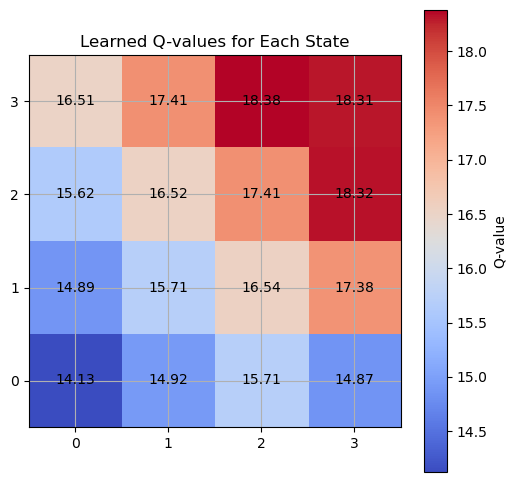

Learned Q-table:
[[12.72852232  5.18793393 11.01173125 14.1250445 ]
 [ 7.5341403  13.64245598  8.96039741 14.92384729]
 [14.09124881 14.09218527 14.74429313 15.70843332]
 [14.86857412 11.87220148  0.         13.85224421]
 [13.49145414 14.88721177 13.33105238 14.06216259]
 [14.10373631 15.71087066 13.98706234 15.57125011]
 [14.86814468 16.08518727 14.91926448 16.53788235]
 [15.65051408 12.84981662 13.24790875 17.37815547]
 [13.53810478 14.08087298 11.152974   15.62381761]
 [13.90825192 16.52390254 11.79871537 16.03391656]
 [15.62864156 17.24688354 15.70664132 17.40830017]
 [14.43935942 16.61327723 13.80162374 18.32450379]
 [14.56263592 16.50674956 14.54431172 15.12187001]
 [13.88296983 17.40732806 14.9710953  16.426527  ]
 [16.46743157 18.37814167 16.5044697  17.33361775]
 [14.10502397 18.30688996 16.53717015 18.1038499 ]]


In [18]:
# Output
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)